In [1]:
import yfinance as yf
import pandas as pd

ticker = "NVDA"
start_date = "2023-01-01"
end_date = "2023-12-31"

df = yf.download(ticker, start=start_date, end=end_date, progress=False)

# Flatten columns if needed
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Ensure datetime index
df.index = pd.to_datetime(df.index)
df = df.sort_index()


C:\Users\weldi\AppData\Local\Temp\ipykernel_14228\2139079314.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import talib as ta


In [4]:
df['Daily_Return'] = df['Close'].pct_change()
df['Cumulative_Return'] = (1 + df['Daily_Return']).cumprod() - 1
df['RSI_14'] = ta.RSI(df['Close'], timeperiod=14)

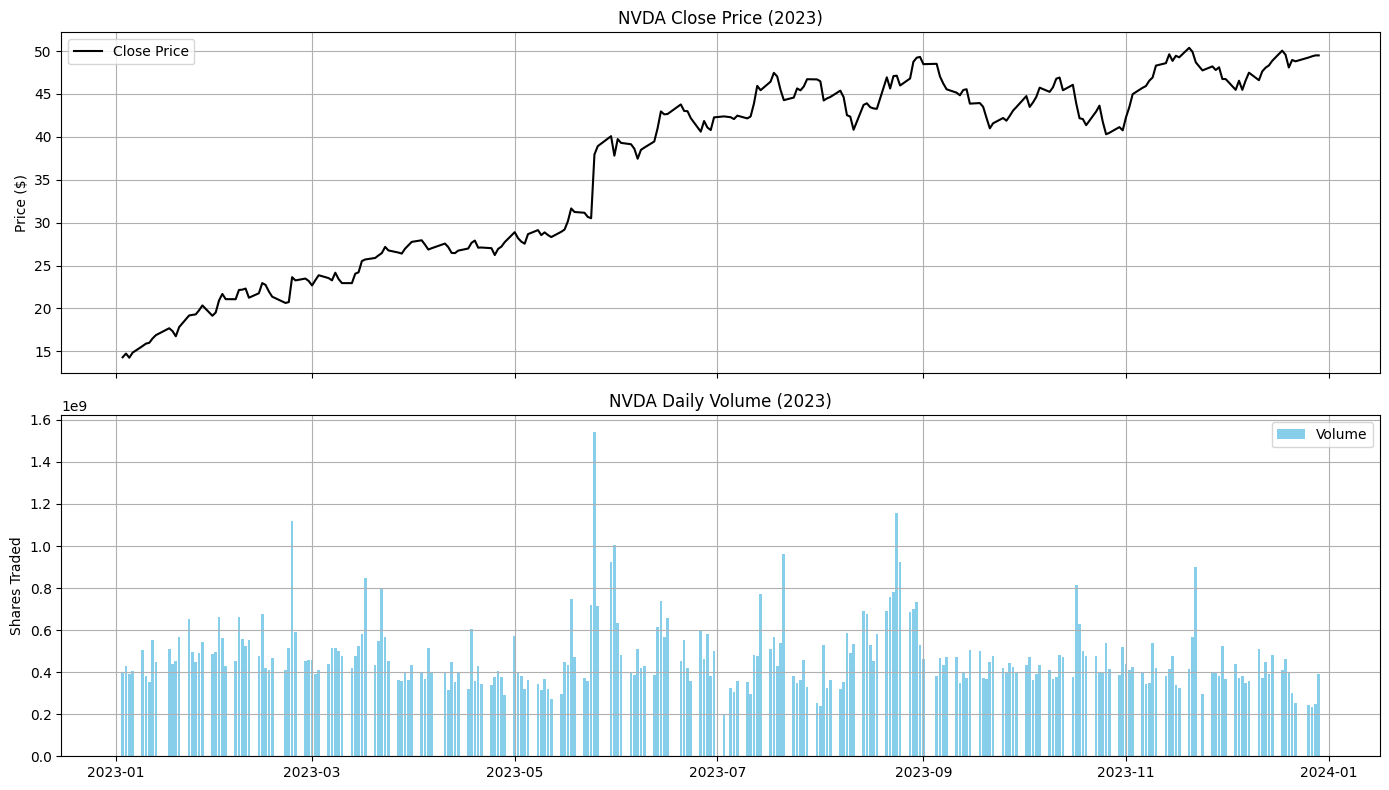

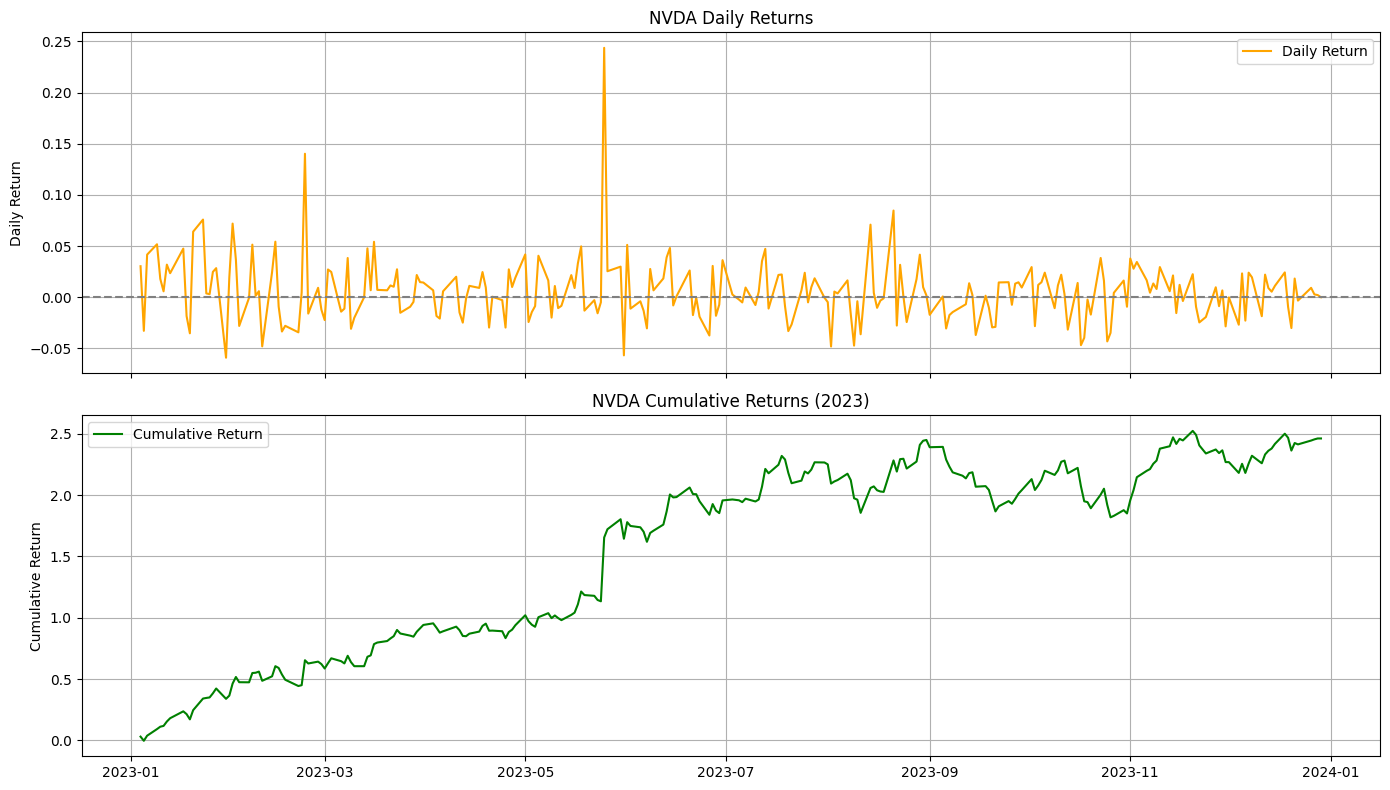

Descriptive statistics for Close, Daily Return, and Cumulative Return:
                   count       mean        std        min        25%  \
Price                                                                  
Close              250.0  36.544537  10.752565  14.251529  26.878908   
Daily_Return       249.0   0.005442   0.030525  -0.059072  -0.013069   
Cumulative_Return  249.0   1.561544   0.746836  -0.003493   0.883380   

                         50%        75%        max  
Price                                               
Close              41.867102  45.616544  50.379303  
Daily_Return        0.004315   0.021308   0.243696  
Cumulative_Return   1.928810   2.191092   2.522664  


In [9]:

# Price, Volume, Daily Returns & Cumulative Returns

import matplotlib.pyplot as plt

# --- Price & Volume ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Close price
ax1.plot(df.index, df['Close'], color='black', label='Close Price')
ax1.set_ylabel('Price ($)')
ax1.set_title('NVDA Close Price (2023)')
ax1.legend()
ax1.grid(True)

# Volume
ax2.bar(df.index, df['Volume'], color='skyblue', label='Volume')
ax2.set_ylabel('Shares Traded')
ax2.set_title('NVDA Daily Volume (2023)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


# --- Daily Returns & Cumulative Returns ---
fig, (ax3, ax4) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Daily Returns
ax3.plot(df.index, df['Daily_Return'], color='orange', label='Daily Return')
ax3.set_ylabel('Daily Return')
ax3.set_title('NVDA Daily Returns')
ax3.axhline(0, color='gray', linestyle='--')
ax3.legend()
ax3.grid(True)

# Cumulative Returns
ax4.plot(df.index, df['Cumulative_Return'], color='green', label='Cumulative Return')
ax4.set_ylabel('Cumulative Return')
ax4.set_title('NVDA Cumulative Returns (2023)')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()


# Descriptive stats
print("Descriptive statistics for Close, Daily Return, and Cumulative Return:")
print(df[['Close','Daily_Return','Cumulative_Return']].describe().T)


In [9]:
import talib


df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
df['SMA_50'] = talib.SMA(df['Close'], timeperiod=50)


df['RSI'] = talib.RSI(df['Close'], timeperiod=14)


df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(df['Close'], fastperiod=12, slowperiod=26, signalperiod=9)

print(df.tail())


Price           Close       High        Low       Open     Volume  \
Date                                                                
2023-12-22  48.805531  49.358251  48.442710  49.170345  252507000   
2023-12-26  49.254299  49.575137  48.935459  48.943454  244200000   
2023-12-27  49.392235  49.655103  49.060400  49.486189  233648000   
2023-12-28  49.497181  49.858999  49.387235  49.618122  246587000   
2023-12-29  49.497181  49.971945  48.726567  49.788035  389293000   

Price       Daily_Return  Cumulative_Return     RSI_14     SMA_20     SMA_50  \
Date                                                                           
2023-12-22     -0.326589           2.412621  64.502614  47.706983  46.257777   
2023-12-26      0.919504           2.444000  62.503412  47.759019  46.334178   
2023-12-27      0.280048           2.453645  69.719877  47.838989  46.400666   
2023-12-28      0.212475           2.460983  66.371978  47.908266  46.512367   
2023-12-29      0.000000           2

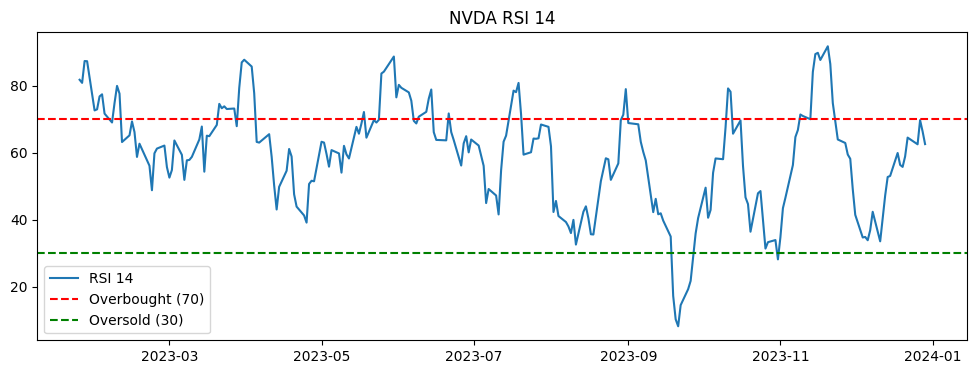

In [8]:
import pandas as pd
import matplotlib.pyplot as plt


df['Close'] = df['Close']


delta = df['Close'].diff()

# Separate gains and losses
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

# Calculate rolling averages
avg_gain = gain.rolling(window=14, min_periods=14).mean()
avg_loss = loss.rolling(window=14, min_periods=14).mean()

# Compute RSI
rs = avg_gain / avg_loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# Plot RSI
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df['RSI_14'], label='RSI 14')
ax.axhline(70, color='red', linestyle='--', label='Overbought (70)')
ax.axhline(30, color='green', linestyle='--', label='Oversold (30)')
ax.set_title('NVDA RSI 14')
ax.legend()
plt.show()


In [6]:
import pandas as pd


df['Daily_Return'] = df['Close'].pct_change() * 100  
df[['Close', 'Daily_Return']].head()



Price,Close,Daily_Return
Date,,
2023-01-03,14.301480,NaN
2023-01-04,14.735071,3.031790
2023-01-05,14.251527,-3.281588
2023-01-06,14.844966,4.164039
2023-01-09,15.613239,5.175312


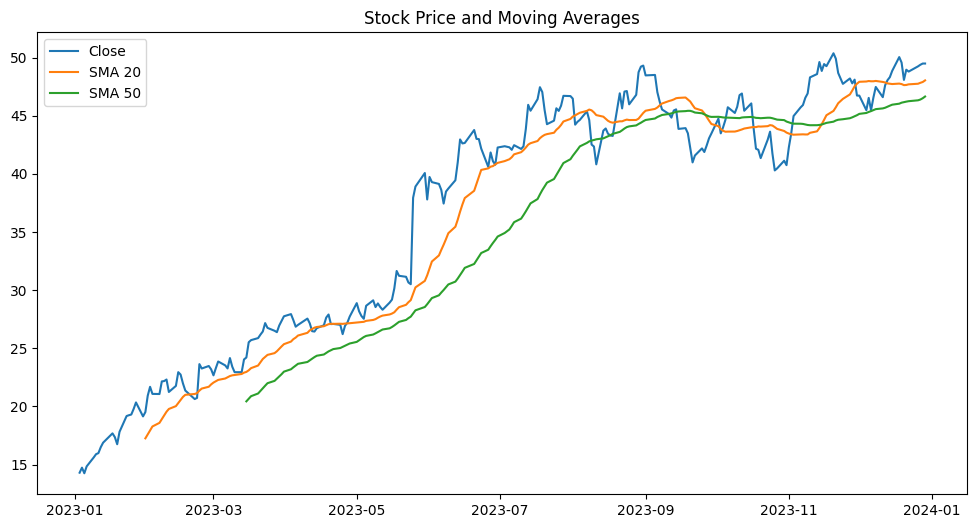

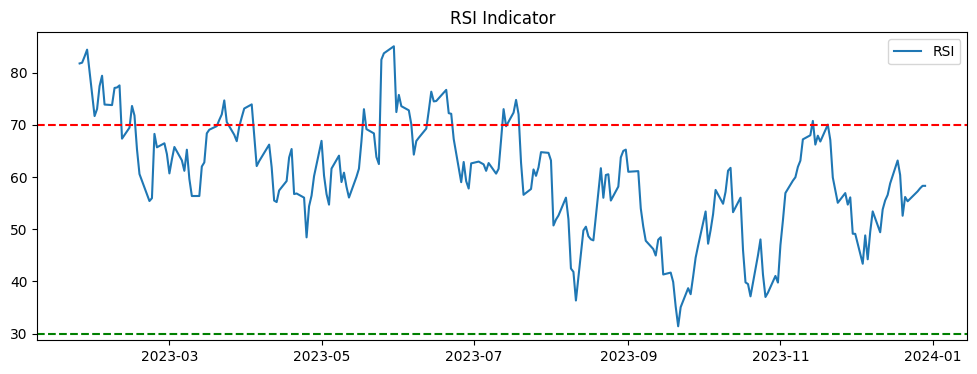

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close')
plt.plot(df['SMA_20'], label='SMA 20')
plt.plot(df['SMA_50'], label='SMA 50')
plt.title('Stock Price and Moving Averages')
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df['RSI'], label='RSI')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title('RSI Indicator')
plt.legend()
plt.show()


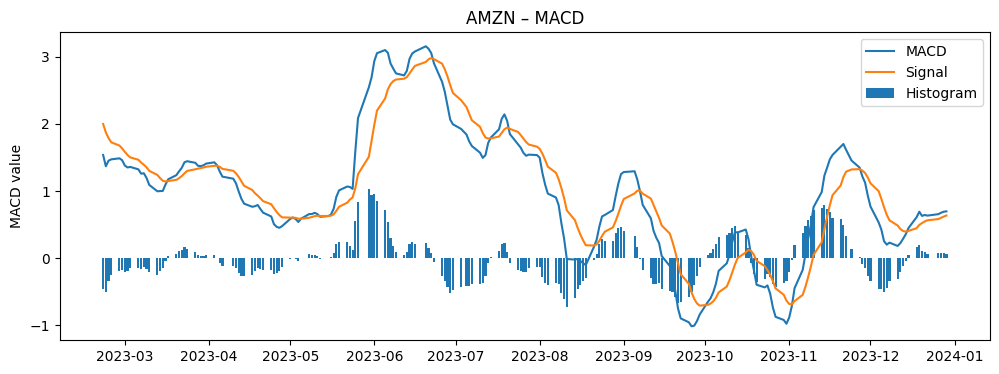

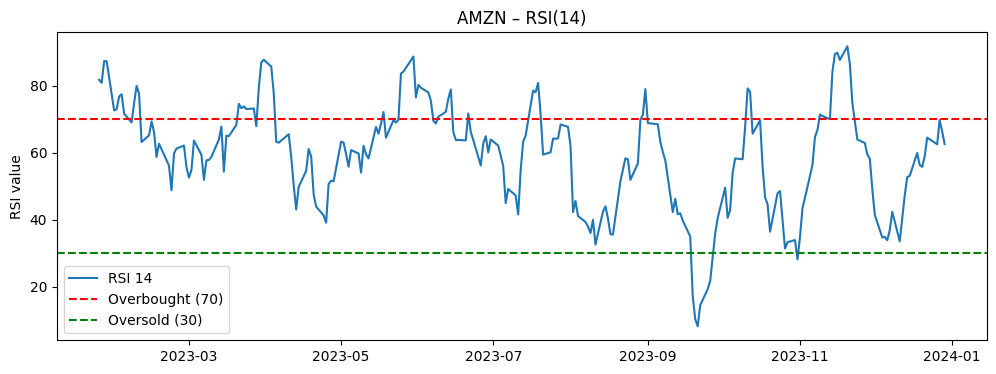

In [12]:

# MACD – Trend & momentum

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["MACD"], label="MACD")
ax.plot(df.index, df["MACD_signal"], label="Signal")
ax.bar(df.index, df["MACD_hist"], label="Histogram")

ax.set_title("AMZN – MACD")
ax.set_ylabel("MACD value")
ax.legend()
plt.show()



# RSI – Overbought / Oversold


fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["RSI_14"], label="RSI 14")
ax.axhline(70, color="red", linestyle="--", label="Overbought (70)")
ax.axhline(30, color="green", linestyle="--", label="Oversold (30)")

ax.set_title("AMZN – RSI(14)")
ax.set_ylabel("RSI value")
ax.legend()
plt.show()


In [1]:
# Step 5: PyNance Portfolio Metrics
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from pynance import portfolio_optimizer as po

# Select tickers for your portfolio
ticker_list = [ 'AAPL', 'NVDA']

# Create a PortfolioCalculations object
portfolio = po.PortfolioCalculations(ticker_list)

# Max Sharpe Portfolio
max_sharpe_rr = portfolio.max_sharpe_portfolio('rr')
max_sharpe_df = portfolio.max_sharpe_portfolio('df')
print("Max Sharpe Portfolio Risk/Return:")
print(max_sharpe_rr)
print("\nPortfolio Weights:")
print(max_sharpe_df)

# Min Variance Portfolio
min_var_rr = portfolio.min_var_portfolio('rr')
min_var_df = portfolio.min_var_portfolio('df')
print("\nMin Variance Portfolio Risk/Return:")
print(min_var_rr)
print("\nPortfolio Weights (Min Variance):")
print(min_var_df)

# Efficient Frontier Plot
fig = portfolio.efficient_frontier()
fig.show()


Max Sharpe Portfolio Risk/Return:
                   Max Sharpe Portfolio
Expected Return                  83.12%
Standard Deviation               47.26%

Portfolio Weights:
     Portfolio Weight
AAPL           10.23%
NVDA           89.77%

Min Variance Portfolio Risk/Return:
                   Min Var Portfolio
Expected Return               19.73%
Standard Deviation            24.64%

Portfolio Weights (Min Variance):
     Portfolio Weight
AAPL          100.00%
NVDA            0.00%
    Expected Return  Standard Deviation      AAPL      NVDA
0            0.1972              0.2464  1.000000  0.000000
1            0.1987              0.2465  0.997646  0.002354
2            0.2001              0.2465  0.995190  0.004810
3            0.2015              0.2466  0.992734  0.007266
4            0.2029              0.2467  0.990277  0.009723
5            0.2043              0.2467  0.987821  0.012179
6            0.2058              0.2468  0.985365  0.014635
7            0.2072            